# Ejercicio 7 - CNN con image augmentation

Este notebook reentrena las dos arquitecturas de CNN (cnn_simple.ipynb y cnn_profunda.ipynb) agregando el pipeline de augmentation definido en augmentation.py. Los notebooks originales (cnn_simple.ipynb, cnn_profunda.ipynb) y sus modelos guardados en models/ quedan sin tocar, esas son las versiones sin transformar. Aquí se entrena una segunda versión de cada arquitectura con augmentation y se guarda en models/ como cnn_simple_augmented.keras y cnn_profunda_augmented.keras.

La comparación contra el resto de modelos (base, otros algoritmos) se hace más adelante, cuando estén todos reentrenados.

In [1]:
from pathlib import Path

import numpy as np

DATA_PATH = Path("asl-alphabet/processed/asl_64x64_600pc.npz")
assert DATA_PATH.exists(), f"No se encontró {DATA_PATH}. Corre primero preprocesamiento.ipynb"

data = np.load(DATA_PATH, allow_pickle=True)

X_train, y_train = data["X_train"], data["y_train"]
X_val, y_val = data["X_val"], data["y_val"]
X_test, y_test = data["X_test"], data["y_test"]
class_names = data["class_names"]

print("Train:", X_train.shape, y_train.shape)
print("Val:  ", X_val.shape, y_val.shape)
print("Test: ", X_test.shape, y_test.shape)
print("Clases:", list(class_names))

Train: (12180, 64, 64, 3) (12180,)
Val:   (2610, 64, 64, 3) (2610,)
Test:  (2610, 64, 64, 3) (2610,)
Clases: [np.str_('A'), np.str_('B'), np.str_('C'), np.str_('D'), np.str_('E'), np.str_('F'), np.str_('G'), np.str_('H'), np.str_('I'), np.str_('J'), np.str_('K'), np.str_('L'), np.str_('M'), np.str_('N'), np.str_('O'), np.str_('P'), np.str_('Q'), np.str_('R'), np.str_('S'), np.str_('T'), np.str_('U'), np.str_('V'), np.str_('W'), np.str_('X'), np.str_('Y'), np.str_('Z'), np.str_('del'), np.str_('nothing'), np.str_('space')]


In [2]:
X_train = X_train.astype("float32") / 255.0
X_val = X_val.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

NUM_CLASSES = len(class_names)
IMG_SIZE = X_train.shape[1]

print(f"Imagenes de {IMG_SIZE}x{IMG_SIZE}, {NUM_CLASSES} clases")

Imagenes de 64x64, 29 clases


## Pipeline de augmentation

Se importa de augmentation.py en vez de redefinirlo aquí, así se usa exactamente el mismo pipeline que se visualizó y justificó en augmentation.ipynb (rotación, shift, zoom, brillo y contraste, sin flip). Las capas solo transforman la entrada cuando el modelo se llama con training=True, así que en validación y test se comportan como identidad.

In [3]:
from augmentation import get_augmentation_pipeline

data_augmentation = get_augmentation_pipeline()

## CNN simple con augmentation

Misma arquitectura y mismos hiperparámetros que cnn_simple.ipynb (3 bloques de convolución con 16, 32 y 64 filtros, dropout antes de la salida), agregando data_augmentation justo después del Input.

In [4]:
from tensorflow import keras
from tensorflow.keras import layers

keras.utils.set_random_seed(42)

cnn_simple_aug = keras.Sequential([
    layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),
    data_augmentation,

    layers.Conv2D(16, 3, padding="same", activation="relu"),
    layers.MaxPooling2D(),

    layers.Conv2D(32, 3, padding="same", activation="relu"),
    layers.MaxPooling2D(),

    layers.Conv2D(64, 3, padding="same", activation="relu"),
    layers.MaxPooling2D(),

    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(NUM_CLASSES, activation="softmax"),
])

cnn_simple_aug.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

cnn_simple_aug.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ asl_data_augmentation           │ (None, 64, 64, 3)      │             0 │
│ (Sequential)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 64, 64, 16)     │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       524,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 29)             │         3,741 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 551,741 (2.10 MB)

 Trainable params: 551,741 (2.10 MB)

 Non-trainable params: 0 (0.00 B)

In [5]:
early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=3, restore_best_weights=True
)

history_simple_aug = cnn_simple_aug.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=64,
    callbacks=[early_stop],
)

Epoch 1/20


  1/191 ━━━━━━━━━━━━━━━━━━━━ 1:52 594ms/step - accuracy: 0.0781 - loss: 3.3565

  4/191 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - accuracy: 0.0352 - loss: 3.3801   

  7/191 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 0.0446 - loss: 3.3692

 10/191 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 0.0422 - loss: 3.3732

...

181/191 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.7890 - loss: 0.5948

184/191 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.7883 - loss: 0.5961

187/191 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.7879 - loss: 0.5969

190/191 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.7883 - loss: 0.5968

191/191 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - accuracy: 0.7882 - loss: 0.5972 - val_accuracy: 0.9284 - val_loss: 0.2339


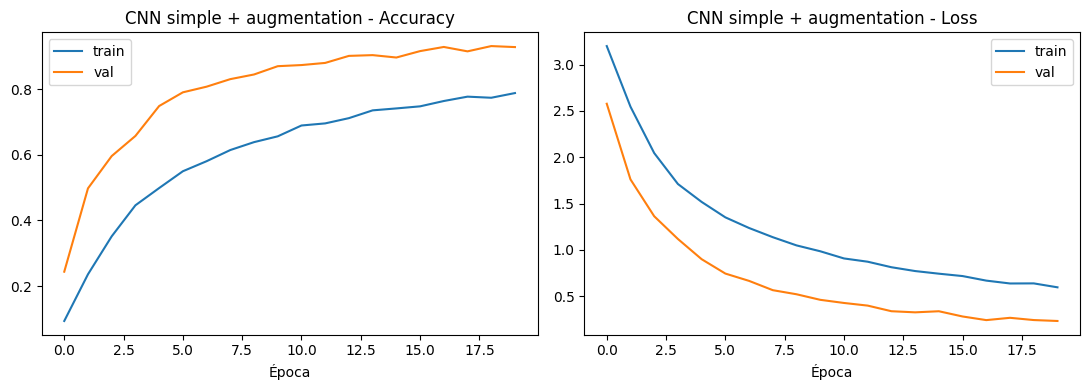

In [6]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(history_simple_aug.history["accuracy"], label="train")
axes[0].plot(history_simple_aug.history["val_accuracy"], label="val")
axes[0].set_title("CNN simple + augmentation - Accuracy")
axes[0].set_xlabel("Época")
axes[0].legend()

axes[1].plot(history_simple_aug.history["loss"], label="train")
axes[1].plot(history_simple_aug.history["val_loss"], label="val")
axes[1].set_title("CNN simple + augmentation - Loss")
axes[1].set_xlabel("Época")
axes[1].legend()

plt.tight_layout()
plt.show()

In [7]:
test_loss_simple_aug, test_acc_simple_aug = cnn_simple_aug.evaluate(X_test, y_test, verbose=0)
print(f"Accuracy en test: {test_acc_simple_aug:.4f}")
print(f"Loss en test: {test_loss_simple_aug:.4f}")

Accuracy en test: 0.9226
Loss en test: 0.2402


In [8]:
from sklearn.metrics import classification_report

y_pred_simple_aug = cnn_simple_aug.predict(X_test, verbose=0).argmax(axis=1)
print(classification_report(y_test, y_pred_simple_aug, target_names=class_names))

              precision    recall  f1-score   support

           A       0.81      0.93      0.87        90
           B       0.92      0.93      0.93        90
           C       1.00      0.99      0.99        90
           D       0.96      0.91      0.94        90
           E       0.95      0.84      0.89        90
           F       0.99      0.98      0.98        90
           G       0.95      0.93      0.94        90
           H       0.98      0.96      0.97        90
           I       1.00      0.89      0.94        90
           J       0.96      1.00      0.98        90
           K       0.88      0.82      0.85        90
           L       1.00      1.00      1.00        90
           M       0.94      0.74      0.83        90
           N       0.91      0.87      0.89        90
           O       0.92      1.00      0.96        90
           P       0.98      1.00      0.99        90
           Q       1.00      0.97      0.98        90
           R       0.97    

In [9]:
MODELS_DIR = Path("models")
MODELS_DIR.mkdir(exist_ok=True)

cnn_simple_aug.save(MODELS_DIR / "cnn_simple_augmented.keras")
print("Modelo guardado en", (MODELS_DIR / "cnn_simple_augmented.keras").resolve())

Modelo guardado en /Users/nilsmurallesmorales/universidad/octavosemestre/data/lab3/models/cnn_simple_augmented.keras


## CNN profunda con augmentation

Misma arquitectura y mismos hiperparámetros que cnn_profunda.ipynb (4 bloques de convolución con 32, 64, 128 y 256 filtros, batch normalization, learning rate 3e-4), agregando data_augmentation justo después del Input.

In [10]:
keras.utils.set_random_seed(42)

def conv_block(x, filters):
    x = layers.Conv2D(filters, 3, padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.MaxPooling2D()(x)
    return x

inputs = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = data_augmentation(inputs)
x = conv_block(x, 32)
x = conv_block(x, 64)
x = conv_block(x, 128)
x = conv_block(x, 256)

x = layers.Flatten()(x)
x = layers.Dense(256, activation="relu")(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(NUM_CLASSES, activation="softmax")(x)

cnn_profunda_aug = keras.Model(inputs, outputs)

cnn_profunda_aug.compile(
    optimizer=keras.optimizers.Adam(learning_rate=3e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

cnn_profunda_aug.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ asl_data_augmentation           │ (None, 64, 64, 3)      │             0 │
│ (Sequential)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 32)     │           864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 64)     │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 16, 16, 128)    │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 8, 8, 256)      │       294,912 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 8, 8, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │     1,048,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 29)             │         7,453 │
└─────────────────────────────────┴────────────────────────┴─────────────

 Total params: 1,446,141 (5.52 MB)

 Trainable params: 1,445,181 (5.51 MB)

 Non-trainable params: 960 (3.75 KB)

In [11]:
early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=5, restore_best_weights=True
)

history_profunda_aug = cnn_profunda_aug.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=25,
    batch_size=64,
    callbacks=[early_stop],
)

Epoch 1/25


  1/191 ━━━━━━━━━━━━━━━━━━━━ 3:09 997ms/step - accuracy: 0.0312 - loss: 4.7983

  2/191 ━━━━━━━━━━━━━━━━━━━━ 16s 85ms/step - accuracy: 0.0469 - loss: 4.7327  

  3/191 ━━━━━━━━━━━━━━━━━━━━ 16s 85ms/step - accuracy: 0.0573 - loss: 4.7340

  4/191 ━━━━━━━━━━━━━━━━━━━━ 15s 85ms/step - accuracy: 0.0508 - loss: 4.6875

...

187/191 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - accuracy: 0.8610 - loss: 0.3784

188/191 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - accuracy: 0.8607 - loss: 0.3794

189/191 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - accuracy: 0.8612 - loss: 0.3784

190/191 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - accuracy: 0.8614 - loss: 0.3781

191/191 ━━━━━━━━━━━━━━━━━━━━ 17s 89ms/step - accuracy: 0.8614 - loss: 0.3780 - val_accuracy: 0.9544 - val_loss: 0.1334


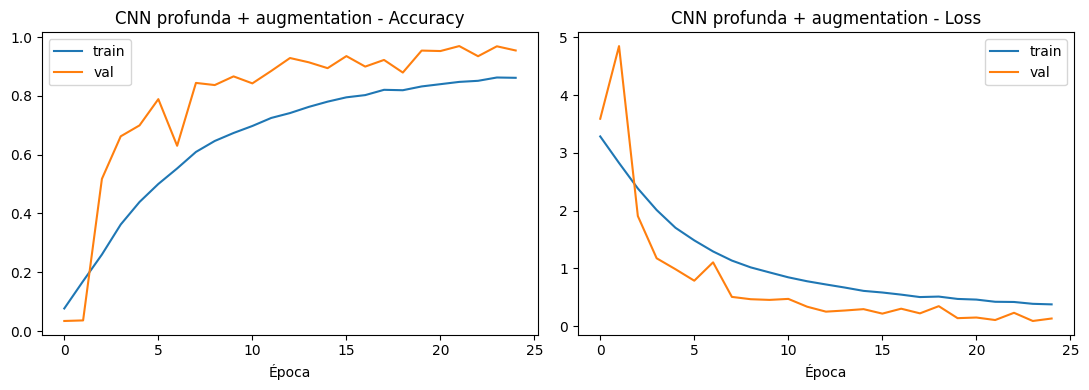

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(history_profunda_aug.history["accuracy"], label="train")
axes[0].plot(history_profunda_aug.history["val_accuracy"], label="val")
axes[0].set_title("CNN profunda + augmentation - Accuracy")
axes[0].set_xlabel("Época")
axes[0].legend()

axes[1].plot(history_profunda_aug.history["loss"], label="train")
axes[1].plot(history_profunda_aug.history["val_loss"], label="val")
axes[1].set_title("CNN profunda + augmentation - Loss")
axes[1].set_xlabel("Época")
axes[1].legend()

plt.tight_layout()
plt.show()

In [13]:
test_loss_profunda_aug, test_acc_profunda_aug = cnn_profunda_aug.evaluate(X_test, y_test, verbose=0)
print(f"Accuracy en test: {test_acc_profunda_aug:.4f}")
print(f"Loss en test: {test_loss_profunda_aug:.4f}")

Accuracy en test: 0.9655
Loss en test: 0.1011


In [14]:
y_pred_profunda_aug = cnn_profunda_aug.predict(X_test, verbose=0).argmax(axis=1)
print(classification_report(y_test, y_pred_profunda_aug, target_names=class_names))

              precision    recall  f1-score   support

           A       0.98      0.97      0.97        90
           B       0.95      0.93      0.94        90
           C       1.00      0.99      0.99        90
           D       1.00      0.98      0.99        90
           E       1.00      0.94      0.97        90
           F       1.00      1.00      1.00        90
           G       0.98      1.00      0.99        90
           H       0.98      0.98      0.98        90
           I       0.99      0.98      0.98        90
           J       1.00      0.99      0.99        90
           K       0.93      0.89      0.91        90
           L       1.00      1.00      1.00        90
           M       0.87      1.00      0.93        90
           N       1.00      0.86      0.92        90
           O       0.98      1.00      0.99        90
           P       1.00      0.96      0.98        90
           Q       0.98      1.00      0.99        90
           R       0.89    

In [15]:
cnn_profunda_aug.save(MODELS_DIR / "cnn_profunda_augmented.keras")
print("Modelo guardado en", (MODELS_DIR / "cnn_profunda_augmented.keras").resolve())

Modelo guardado en /Users/nilsmurallesmorales/universidad/octavosemestre/data/lab3/models/cnn_profunda_augmented.keras
